# Khởi tạo và nạp vào dữ liệu đã được làm sạch

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df_eda = pd.read_csv('../data/processed/housing_clean.csv')
print(f"Dữ liệu sẵn sàng cho EDA: {df_eda.shape[0]:,} dòng, {df_eda.shape[1]} cột.")

Dữ liệu sẵn sàng cho EDA: 45,857 dòng, 8 cột.


# Phân phối các đặc trưng số (Numerical Distributions)

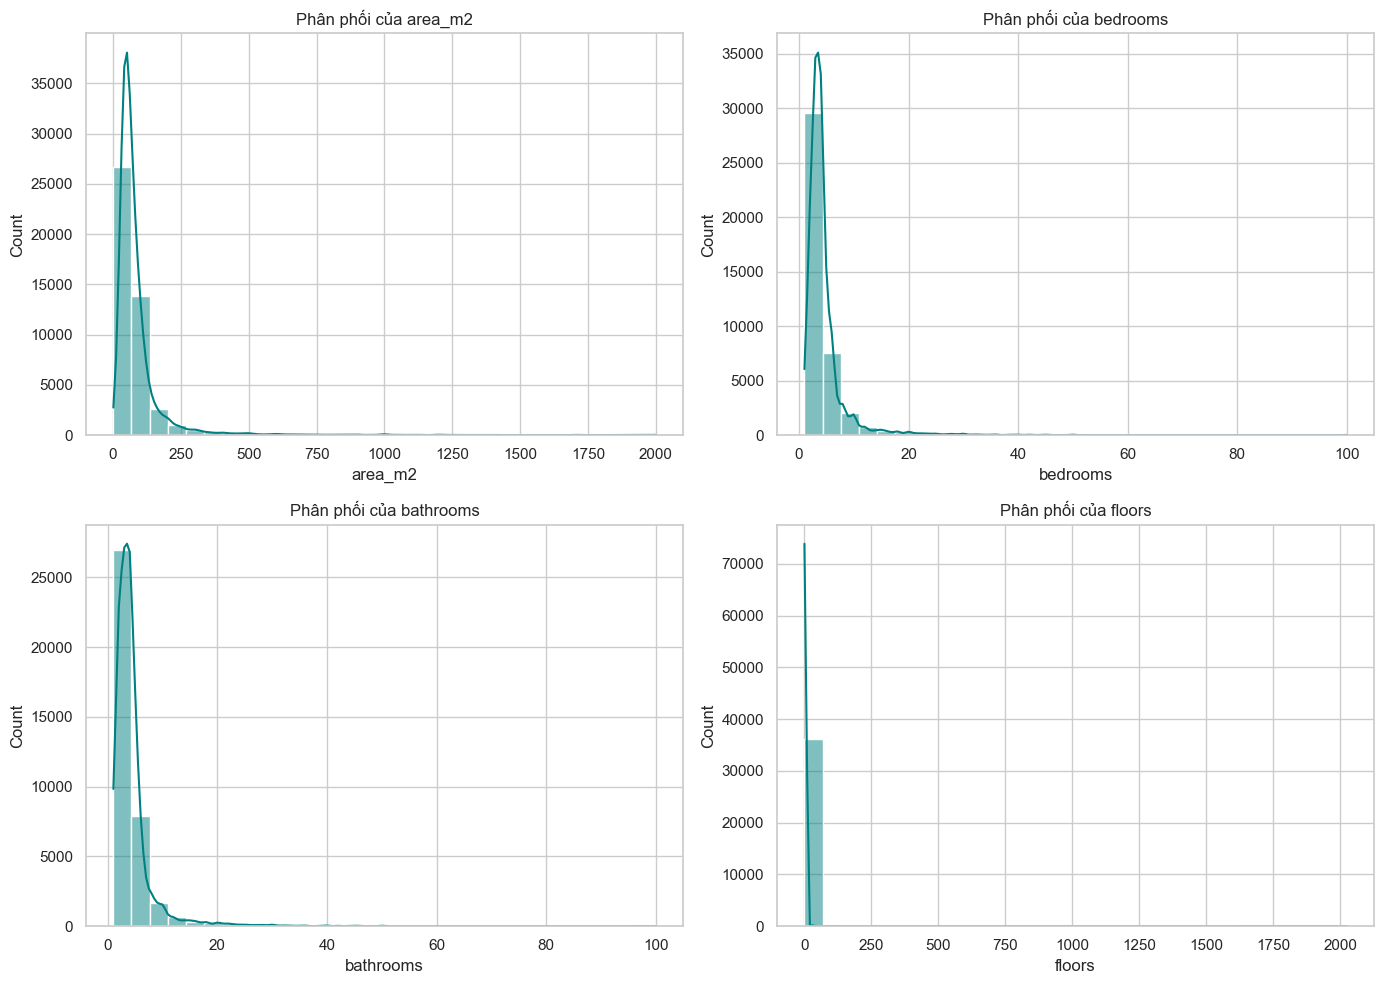

In [2]:
# Xem xét các biến độc lập tập trung ở khoảng giá trị nào
numerical_features = ['area_m2', 'bedrooms', 'bathrooms', 'floors']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df_eda[col], bins=30, kde=True, color='teal', ax=axes[i])
    axes[i].set_title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

# Khám phá giả định cốt lõi (Area vs Price)

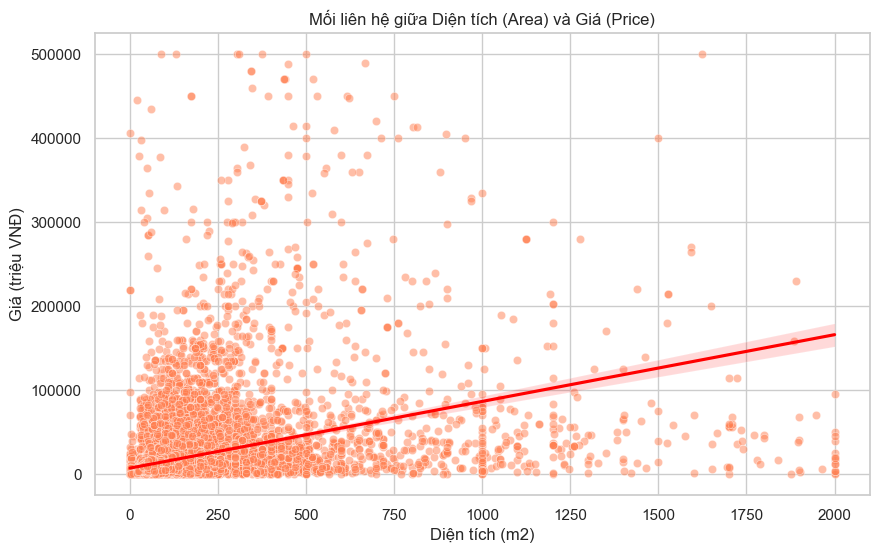

In [3]:
# Kiểm tra xem diện tích tăng thì giá có tăng tuyến tính hay không
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='area_m2', y='price_million_vnd', alpha=0.5, color='coral')

# Vẽ thêm đường xu hướng (Trendline)
sns.regplot(data=df_eda, x='area_m2', y='price_million_vnd', scatter=False, color='red')

plt.title('Mối liên hệ giữa Diện tích (Area) và Giá (Price)')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (triệu VNĐ)')
plt.show()

# Khám phá yếu tố phân loại (Location & Frontage)

C:\Users\USER\AppData\Local\Temp\ipykernel_21776\1877874279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='frontage', y='price_million_vnd', palette='Set2', ax=axes[0])


C:\Users\USER\AppData\Local\Temp\ipykernel_21776\1877874279.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_loc, y='location', x='price_million_vnd', palette='viridis', ax=axes[1])


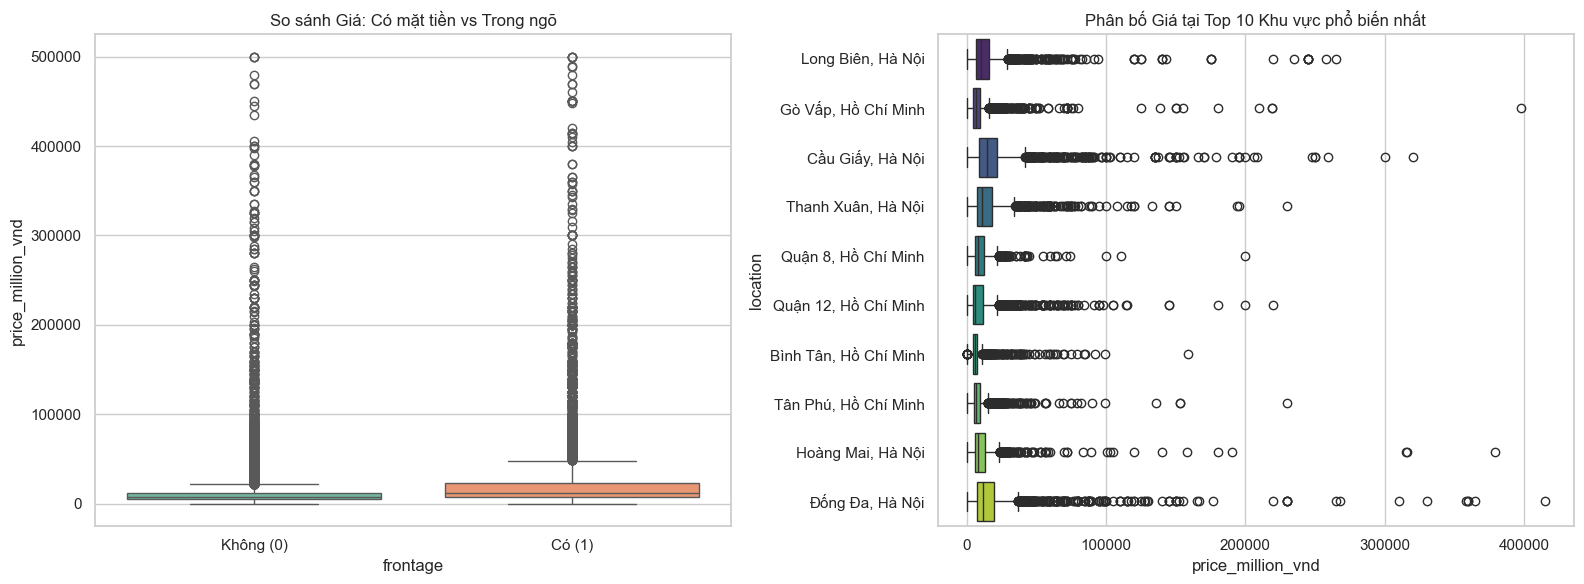

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phân tích Frontage (Mặt tiền: 1 = Có, 0 = Không)
sns.boxplot(data=df_eda, x='frontage', y='price_million_vnd', palette='Set2', ax=axes[0])
axes[0].set_title('So sánh Giá: Có mặt tiền vs Trong ngõ')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Không (0)', 'Có (1)'])

# Phân tích Location (Chỉ lấy Top 10 khu vực nhiều tin đăng nhất để biểu đồ không bị rối)
top_10_locations = df_eda['location'].value_counts().nlargest(10).index
df_top_loc = df_eda[df_eda['location'].isin(top_10_locations)]

sns.boxplot(data=df_top_loc, y='location', x='price_million_vnd', palette='viridis', ax=axes[1])
axes[1].set_title('Phân bố Giá tại Top 10 Khu vực phổ biến nhất')

plt.tight_layout()
plt.show()

Ma trận tương quan (Correlation Matrix)

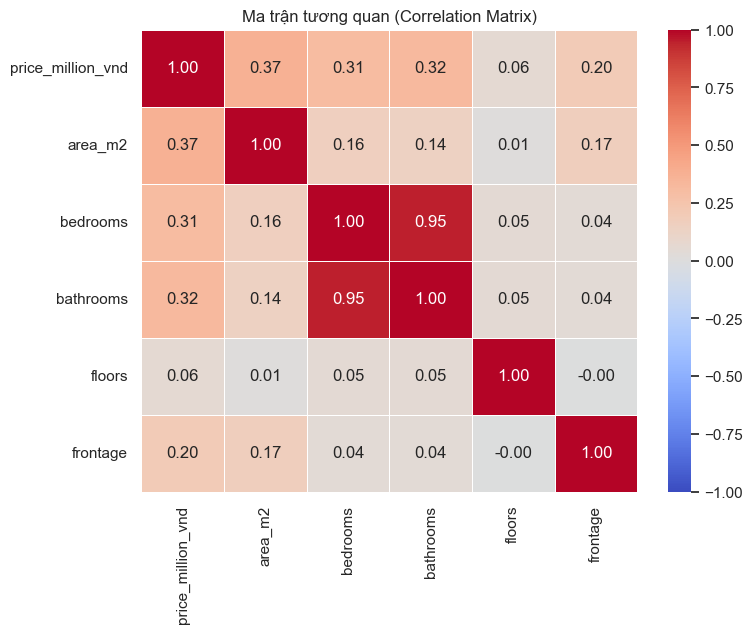

In [5]:
# Tính hệ số tương quan Pearson giữa các biến số
# Hệ số càng gần 1 hoặc -1 thì biến đó càng tốt cho Linear Regression
corr_cols = ['price_million_vnd', 'area_m2', 'bedrooms', 'bathrooms', 'floors', 'frontage']
corr_matrix = df_eda[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix)')
plt.show()

Kết quả từ quá trình Khám phá Dữ liệu (EDA) cho thấy mô hình hồi quy tuyến tính sẽ không đạt hiệu quả nếu chỉ dùng nguyên trạng các đặc trưng số học, đòi hỏi chiến lược Feature Engineering phải can thiệp sâu hơn.

* Xung đột Đa cộng tuyến (Multicollinearity): Cặp biến bedrooms và bathrooms trùng lặp thông tin nghiêm trọng (tương quan 0.91), bắt buộc phải loại bỏ một biến (ưu tiên bỏ bathrooms vì tương quan với giá thấp hơn một chút) để bảo vệ tính ổn định của các hệ số hồi quy.

* Nghịch lý Biến diện tích: Tương quan rất yếu (0.13) minh chứng rằng diện tích đứng độc lập không quyết định được giá trị. Đặc trưng này chỉ phát huy sức mạnh dự đoán khi được đặt vào bối cảnh vị trí địa lý cụ thể.

* Dữ liệu nhiễu: Biến floors (0.03) gần như vô giá trị trong việc giải thích sự biến thiên của giá nhà, nên được đưa vào danh sách cân nhắc lược bỏ để tránh làm loãng mô hình.
